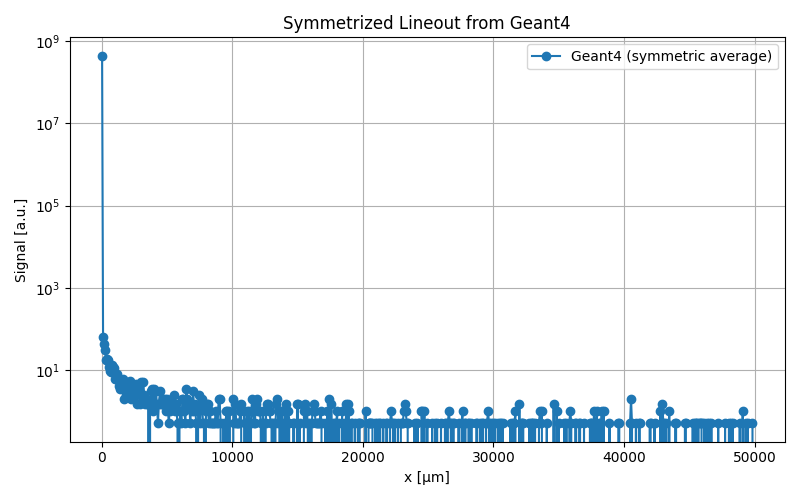

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load data ---
data = np.load("/home/yu79deg/darkfield_p5438/Air_scattering/xray_Primaries2e9_50umKapton_Air_stats.npz")
x_particles = data["x"]
y_particles = data["y"]

# --- Parameters ---
pixel_size = 75  # µm
y_center = 0
band_width = 75  # +/- band for horizontal slice

# --- Filter particles around horizontal center line ---
mask = np.abs(y_particles - y_center) < (band_width / 2)
x_filtered = x_particles[mask]

# --- Symmetric binning around x = 0 ---
x_abs_max = np.max(np.abs(x_filtered))
n_bins = int(np.ceil((2 * x_abs_max) / pixel_size))
# Make sure bins are symmetric around 0
bins = np.linspace(-n_bins//2 * pixel_size, n_bins//2 * pixel_size, n_bins + 1)

hist, edges = np.histogram(x_filtered, bins=bins)
bin_centers = 0.5 * (edges[:-1] + edges[1:])

# --- Average symmetric bins ---
# Only keep x ≥ 0
mid = len(hist) // 2
if len(hist) % 2 == 0:
    pos_hist = hist[mid:]
    neg_hist = hist[:mid][::-1]
    avg_hist = 0.5 * (pos_hist + neg_hist)
    avg_centers = bin_centers[mid:]
else:
    pos_hist = hist[mid+1:]
    neg_hist = hist[:mid][::-1]
    avg_hist = 0.5 * (pos_hist + neg_hist)
    avg_centers = bin_centers[mid+1:]

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(avg_centers, avg_hist, label="Geant4 (symmetric average)", marker='o')

plt.xlabel("x [µm]")
plt.ylabel("Signal [a.u.]")
plt.title("Symmetrized Lineout from Geant4")
plt.grid(True)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()
